### understanding what librosa.load actually returns

In [ ]:
import librosa
import numpy as np

y, sr = librosa.load('../data/genres_original/blues/blues.00000.wav',duration = 30)

print(type(y))
print(y.shape)
print(sr)
print(y[:10])


c:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<class 'numpy.ndarray'>
(661500,)
22050
[ 0.00732422  0.01660156  0.00762939 -0.00350952 -0.0022583  -0.0093689
 -0.02267456 -0.02236938 -0.03128052 -0.04330444]


### visualise the waveform before extracting anything


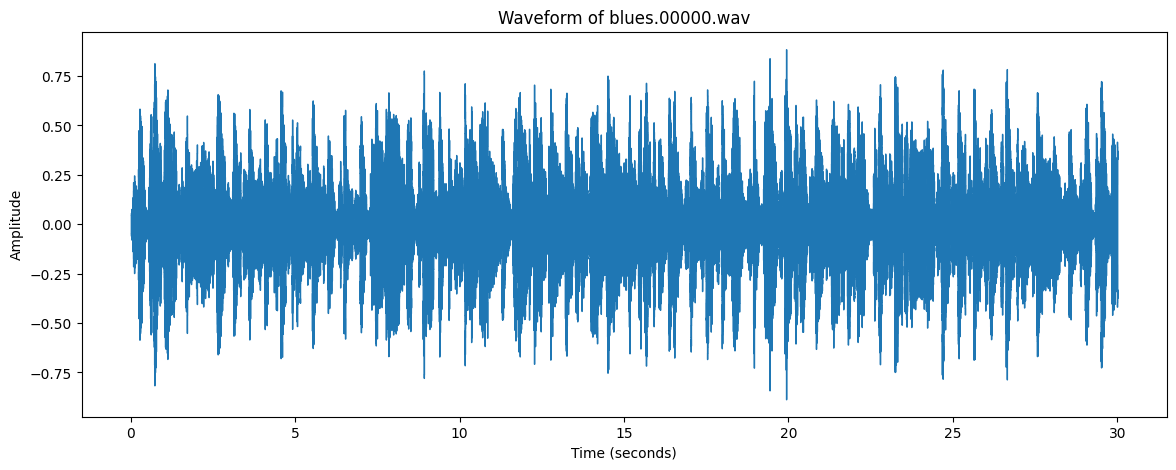

In [2]:
import matplotlib.pyplot as plt
import librosa.display

plt.figure(figsize=(14, 5))
librosa.display.waveshow(y, sr=sr)
plt.title('Waveform of blues.00000.wav')
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude')
plt.show()

### BPM, and what "beat tracking" actually means

In [3]:
tempo, beat_frames = librosa.beat.beat_track(y=y, sr=sr)
print(type(tempo))
print(f"Estimated BPM: {tempo[0]:.1f}")
print(f"Number of beats detected: {len(beat_frames)}")
print(f"First 5 beat positions (in frames): {beat_frames[:5]}")

# Convert frame positions to time in seconds
beat_times = librosa.frames_to_time(beat_frames, sr=sr)
print(f"First 5 beat times (seconds): {beat_times[:5]}")

<class 'numpy.ndarray'>
Estimated BPM: 123.0
Number of beats detected: 61
First 5 beat positions (in frames): [ 32  53  73  94 114]
First 5 beat times (seconds): [0.74303855 1.2306576  1.69505669 2.18267574 2.64707483]


### MFCC- Mel-Frequency Cepstral Coefficients

MFCCs shape: (13, 1292)


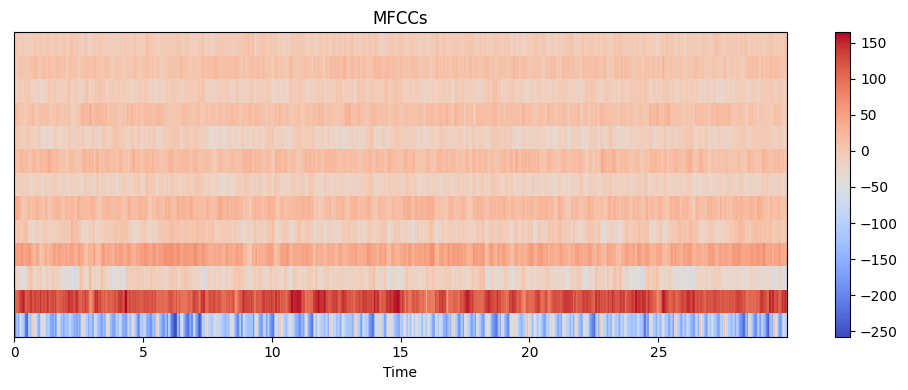

In [4]:
mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)

print("MFCCs shape:", mfccs.shape)

plt.figure(figsize=(10, 4))
librosa.display.specshow(mfccs, x_axis='time')
plt.colorbar()
plt.title('MFCCs')
plt.tight_layout()
plt.show()

In [5]:
mfcc_means = np.mean(mfccs, axis=1)
print(f"Shape after mean: {mfcc_means.shape}")  # (13,)
print(mfcc_means)

Shape after mean: (13,)
[-113.619385   121.55302    -19.151058    42.345768    -6.3711677
   18.613033   -13.69206     15.339378   -12.283617    10.973775
   -8.32241      8.8067875   -3.665802 ]


In [7]:
files = {
    "blues":     "genres_original/blues/blues.00000.wav",
    "classical": "genres_original/classical/classical.00000.wav",
    "metal":     "genres_original/metal/metal.00000.wav"
}

for genre, path in files.items():
    y, sr = librosa.load(path, duration=30)
    tempo, _ = librosa.beat.beat_track(y=y, sr=sr)
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    means = np.mean(mfccs, axis=1)
    print(f"\n{genre.upper()}")
    print(f"  BPM: {tempo[0]:.1f}")
    print(f"  MFCC 1: {means[0]:.1f}")
    print(f"  MFCC 2: {means[1]:.1f}")
    print(f"  MFCC 3: {means[2]:.1f}")


BLUES
  BPM: 123.0
  MFCC 1: -113.6
  MFCC 2: 121.6
  MFCC 3: -19.2

CLASSICAL
  BPM: 95.7
  MFCC 1: -268.2
  MFCC 2: 135.7
  MFCC 3: -34.1

METAL
  BPM: 95.7
  MFCC 1: -52.9
  MFCC 2: 50.1
  MFCC 3: -11.5


In [9]:
y_blues, sr_blues = librosa.load("genres_original/blues/blues.00000.wav", duration=30)
y_metal, sr_metal = librosa.load("genres_original/metal/metal.00000.wav", duration=30)


cent_blues = np.mean(librosa.feature.spectral_centroid(y=y_blues, sr=sr_blues), axis=1)
cent_metal = np.mean(librosa.feature.spectral_centroid(y=y_metal, sr=sr_metal), axis=1)

zero_cross_blues = np.mean(librosa.feature.zero_crossing_rate(y=y_blues), axis=1)
zero_cross_metal = np.mean(librosa.feature.zero_crossing_rate(y=y_metal), axis=1)

print(f"Spectral Centroid — Blues: {cent_blues[0]:.1f} Hz, Metal: {cent_metal[0]:.1f} Hz")
print(f"Zero Crossing Rate — Blues: {zero_cross_blues[0]:.5f}, Metal: {zero_cross_metal[0]:.5f}")

Spectral Centroid — Blues: 1784.4 Hz, Metal: 3274.3 Hz
Zero Crossing Rate — Blues: 0.08307, Metal: 0.18308


In [10]:
def extract_features(file_path):
    y, sr = librosa.load(file_path, duration=30)
    
    # Rhythm
    tempo, _ = librosa.beat.beat_track(y=y, sr=sr)
    
    # Timbre — 13 numbers describing frequency texture
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    mfcc_means = np.mean(mfccs, axis=1)
    
    # Brightness — where is the energy concentrated?
    centroid = np.mean(librosa.feature.spectral_centroid(y=y, sr=sr))
    
    # Noisiness — how chaotic is the waveform?
    zcr = np.mean(librosa.feature.zero_crossing_rate(y))
    
    # Harmony — which musical keys/notes dominate?
    chroma = np.mean(librosa.feature.chroma_stft(y=y, sr=sr), axis=1)  # 12 numbers
    
    # One flat vector: 1 + 13 + 1 + 1 + 12 = 28 features
    return np.concatenate([[tempo[0]], mfcc_means, [centroid, zcr], chroma])

In [11]:
import os
import pandas as pd

genres = ['blues', 'classical', 'disco', 'hiphop', 'jazz',
          'metal', 'pop', 'reggae', 'rock', 'country']

rows = []
errors = []

for genre in genres:
    folder = f"genres_original/{genre}"
    files = os.listdir(folder)
    print(f"Processing {genre}... ({len(files)} files)")
    
    for filename in files:
        if not filename.endswith(".wav"):
            continue
        path = os.path.join(folder, filename)
        try:
            feats = extract_features(path)
            rows.append([genre] + list(feats))
        except Exception as e:
            errors.append(filename)

print(f"\nDone. {len(rows)} tracks processed, {len(errors)} skipped.")
if errors:
    print(f"Skipped files: {errors}")

Processing blues... (100 files)
Processing classical... (100 files)
Processing disco... (100 files)
Processing hiphop... (100 files)
Processing jazz... (100 files)


C:\Users\Admin\AppData\Local\Temp\ipykernel_12460\370553649.py:2: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(file_path, duration=30)
c:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\librosa\core\audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Processing metal... (100 files)
Processing pop... (100 files)
Processing reggae... (100 files)
Processing rock... (100 files)
Processing country... (100 files)

Done. 999 tracks processed, 1 skipped.
Skipped files: ['jazz.00054.wav']


In [12]:
# Build the dataframe
n_feats = len(rows[0]) - 1
col_names = (["genre"] + ["tempo"] + 
             [f"mfcc_{i}" for i in range(1, 14)] + 
             ["centroid", "zcr"] + 
             [f"chroma_{i}" for i in range(1, 13)])

df = pd.DataFrame(rows, columns=col_names)
df.to_csv("gtzan_features.csv", index=False)

print(df.shape)
df.head(3)

(999, 29)


,genre,tempo,mfcc_1,mfcc_2,mfcc_3,mfcc_4,mfcc_5,mfcc_6,mfcc_7,mfcc_8,...,chroma_3,chroma_4,chroma_5,chroma_6,chroma_7,chroma_8,chroma_9,chroma_10,chroma_11,chroma_12
0,blues,123.046875,-113.619385,121.553017,-19.151058,42.345768,-6.371168,18.613033,-13.692060,15.339378,...,0.439980,0.244634,0.247802,0.335615,0.364576,0.435647,0.295841,0.314634,0.406560,0.384770
1,blues,67.999589,-207.581512,123.997147,8.939115,35.870758,2.919971,21.518787,-8.555368,23.355938,...,0.320969,0.211586,0.200908,0.331005,0.397647,0.560676,0.384379,0.255474,0.284959,0.334238
2,blues,161.499023,-90.776337,140.448608,-29.100559,31.687340,-13.975973,25.741686,-13.644712,11.623112,...,0.315254,0.408135,0.547083,0.321775,0.304787,0.288517,0.334242,0.401911,0.384308,0.588190
